In [1]:
# Determiner Acceptance Efficacite : Ngen / Nrec

# acceptance : geometrique, muon qui partent dans la direction du detecteur
# pas facile a decorreler car difficile a differencier
# probabilite de detection

# tom et mathieu en tienne pas compte des trou dans le detecteur, on leur donne le vrai nombre de J/Psi
# derive de deux facon
# general : 
# et en fonction de la rapidite (invariant de lorentz) (positive dans ALICE, pas la pseudo-rapidite en revenche) : on doit utiliser plusieurs tranche de rapidite (voir avec mathieu et tom les tranches qu'il ont choisi)

#1 - spectre en masse invariante (revoir planif a la fin)
#2 - n reconstruit, n genere
#    rapport en fonction de la rapidite (tranche facilement modifiable)
#3 - correction faite dans les memes conditions : ex : reconstruction impulsion on coupe sur speudo rap pour etre sur que muon dans detecteur; 
#4 - spectre en masse invariant du J/Psi reconstruit
#5 - incertitiude lie a nos choix

In [2]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)

vector.register_awkward() 

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.0.2
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [3]:
# nMuonsGen : Nombre total de trace candidats muons générés dans l’événement 
# nMuons : Nombre total de trace candidats muons dans l’événement 


file = uproot.open("/pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root")  # runXXX.mc.root pour les donnees simulees

gen = file["genTree"]
gen.show()

m = gen.arrays(["nMuonsGen"]) 
m[1].show()

nMuonsGen = 0
for i in range(len(m)):
    info = m[i]["nMuonsGen"]
    nMuonsGen += info
print("nMuonsGen = ", nMuonsGen)

events = file["eventsTree"]

n = events.arrays(["nMuons","Muon_Px","Muon_Py","Muon_Pz","Muon_E","Muon_Charge","Muon_thetaAbs","Muon_matchedTrgThreshold"]) #10000 pour essayer a modifier apres

nMuons = 0
for i in range(len(n)):
    info = n[i]["nMuons"]
    nMuons += info
print("nMuons = ", nMuons)

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
xVtxMC               | double                   | AsDtype('>f8')
yVtxMC               | double                   | AsDtype('>f8')
zVtxMC               | double                   | AsDtype('>f8')
nMuonsGen            | int32_t                  | AsDtype('>i4')
Muon_GenE            | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPx           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPz           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenLabel        | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
Muon_GenMotherPDG... | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
{nMuonsGen: 2}
nMuonsGen =  300000
nMuons =  172503


In [4]:
print(m)
print(n)

[{nMuonsGen: 2}, {nMuonsGen: 2}, {...}, ..., {nMuonsGen: 2}, {nMuonsGen: 2}]
[{nMuons: 2, Muon_Px: [2.02, -0.71], Muon_Py: [...], Muon_Pz: [...], ...}, ...]


In [5]:
#calcul de masse invariante de spectre 

def getTracks(events):
    return ak.zip({"px":events["Muon_Px"],
                       "py":events["Muon_Py"],
                       "pz":events["Muon_Pz"],
                       "E":events["Muon_E"],
                       "charge":events["Muon_Charge"],
                       "thetaAbs":events["Muon_thetaAbs"],
                       "matched":events["Muon_matchedTrgThreshold"]},
                    with_name='Momentum4D')

tracks = getTracks(n)
print(tracks)
print(type(tracks))
a = tracks[1][0]
b = tracks[1][1]
(a+b).M

#a.M() # ou a.mass() pour determine la masse invariante de l'object akward

[[{px: 2.02, py: -0.932, pz: -30.1, E: 30.2, charge: 1, ...}, {...}], ...]
<class 'vector.backends.awkward.MomentumArray4D'>


np.float32(3.4796598)

In [11]:
# Filtrer les événements avec nMuons == 2 et isCMUL == True
filtered_events = m[(m.nMuonsGen == 2)] #& (m.isCMUL)&(abs(m.zVtx)<10)&(m.isCMSH)]

# Initialiser les vecteurs à partir des données des muons
muon_vectors = ak.zip({
    "px": filtered_events.Muon.Px,
    "py": filtered_events.Muon.Py,
    "pz": filtered_events.Muon.Pz,
    "E": filtered_events.Muon.E
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement
invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
masses = (invariant_masses.muon1 + invariant_masses.muon2).mass

# Créer un histogramme des valeurs de la masse
flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_masses, bins=500, color='blue', alpha=0.7)
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()

['nMuonsGen']


AttributeError: no field named 'Muon'

NameError: name 'lt' is not defined

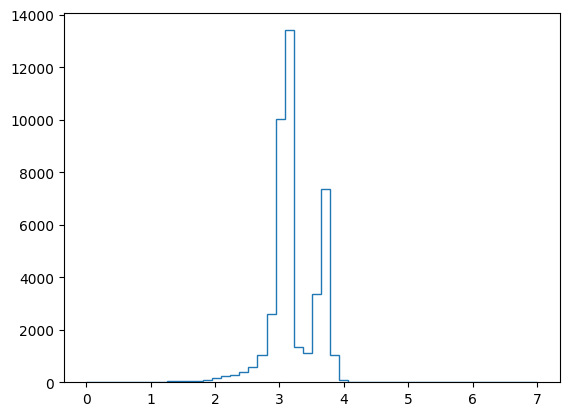

In [12]:
mass_inv = []

for i in range(len(tracks)):
    if len(tracks[i]) == 2: 
        a = tracks[i][0]
        b = tracks[i][1]
        mass = (a+b).M
        mass_inv.append(mass)
        
bins = np.linspace(0, 7, 51)        
plt.hist(mass_inv, bins=bins, histtype='step')
lt.hist(mass_inv, bins=500, color='blue')
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
plt.grid(True)
plt.show()